In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
pd.set_option('display.max_columns',100)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import HistGradientBoostingClassifier



In [2]:
# Loading prepared Dataset for Model Training
df=pd.read_csv("Datasets/ipl_prediction.csv")
df.head()

,match_id,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr,winner
0,212,Rajasthan Royals,Kings XI Punjab,Jaipur,58,70,10,153,11.520000,4.971429,Rajasthan Royals
1,172,Sunrisers Hyderabad,Delhi Capitals,Centurion,17,36,6,153,9.785714,2.833333,Deccan Chargers
2,452,Chennai Super Kings,Royal Challengers Bangalore,Bangalore,40,78,6,106,9.571429,3.076923,Royal Challengers Bangalore
3,380,Delhi Capitals,Chennai Super Kings,Chennai,175,82,8,222,7.578947,12.804878,Chennai Super Kings
4,1,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,82,43,6,207,9.818182,11.441860,Sunrisers Hyderabad


In [3]:
X = df.drop(columns=['winner', 'match_id'])
y = df['winner']

In [4]:
import pickle
le_dict = {}

for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# encode target
le_y = LabelEncoder()
y = le_y.fit_transform(y)
pickle.dump(le_dict, open("encoder.pkl", "wb"))
pickle.dump(le_y, open("target_encoders.pkl", "wb"))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Extra Trees": ExtraTreesClassifier(n_estimators=50,max_depth=8,min_samples_split=10,min_samples_leaf=5,random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "XGBoost": XGBClassifier(eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(),
    "HistGradientBoosting":HistGradientBoostingClassifier(max_depth=6)
}

In [7]:
results = []

for name, model in models.items():
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_acc = cv_scores.mean()
    
    # Train on full training data
    model.fit(X_train, y_train)
    
    # Test prediction
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append([name, cv_acc, acc, f1])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000664 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1075
[LightGBM] [Info] Number of data points in the train set: 46172, number of used features: 9
[LightGBM] [Info] Start training from score -1.888179
[LightGBM] [Info] Start training from score -3.201102
[LightGBM] [Info] Start training from score -4.112087
[LightGBM] [Info] Start training from score -2.430944
[LightGBM] [Info] Start training from score -2.155277
[LightGBM] [Info] Start training from score -2.047303
[LightGBM] [Info] Start training from score -1.824562
[LightGBM] [Info] Start training from score -2.191437
[LightGBM] [Info] Start training from score -2.228753
[LightGBM] [Info] Start training from score -2.551718
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001094 seconds.
You 

In [8]:
results_df = pd.DataFrame(results, columns=[
    "Model", "CV Accuracy", "Test Accuracy", "F1 Score"
])

In [9]:
results_df

,Model,CV Accuracy,Test Accuracy,F1 Score
0,Random Forest,0.999064,0.998822,0.998821
1,Extra Trees,0.865046,0.869776,0.863835
2,Logistic Regression,0.269284,0.261834,0.192212
3,XGBoost,0.999653,0.999653,0.999653
4,LightGBM,0.999723,0.999723,0.999723
5,HistGradientBoosting,0.999723,0.999723,0.999723


In [10]:
safe_models =  ["Extra Trees","HistGradientBoosting"]

filtered_df = results_df[results_df["Model"].isin(safe_models)]

best_model_name = filtered_df.sort_values(
    by="F1 Score", ascending=False
).iloc[0]["Model"]

best_model = models[best_model_name]
best_model

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",6
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtype

In [11]:
with open("Models/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

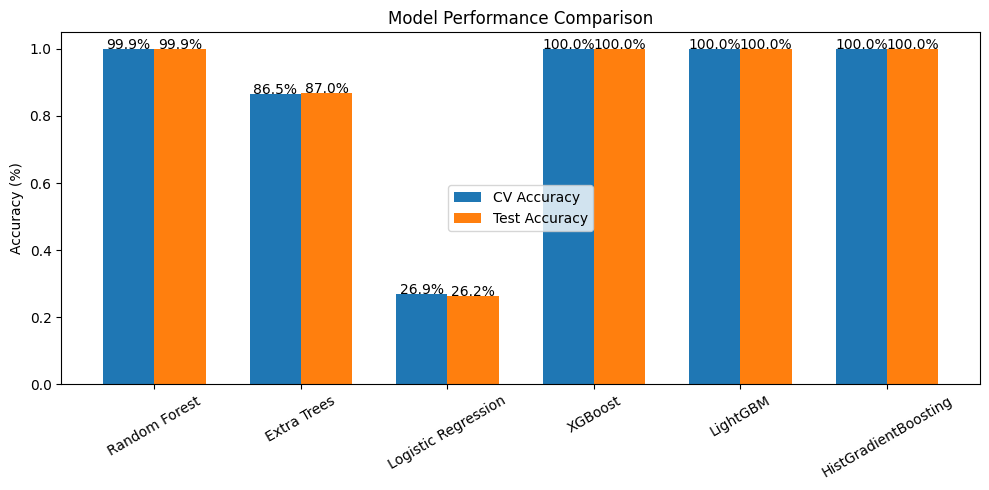

In [12]:
x = np.arange(len(results_df["Model"]))
width = 0.35

plt.figure(figsize=(10,5))

bars1 = plt.bar(x - width/2, results_df["CV Accuracy"], width, label="CV Accuracy")
bars2 = plt.bar(x + width/2, results_df["Test Accuracy"], width, label="Test Accuracy")

plt.xticks(x, results_df["Model"], rotation=30)
plt.ylabel("Accuracy (%)")
plt.title("Model Performance Comparison")

# 🔥 Add values on top (Instagram style)
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height()*100:.1f}%", ha='center')

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height()*100:.1f}%", ha='center')

plt.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()

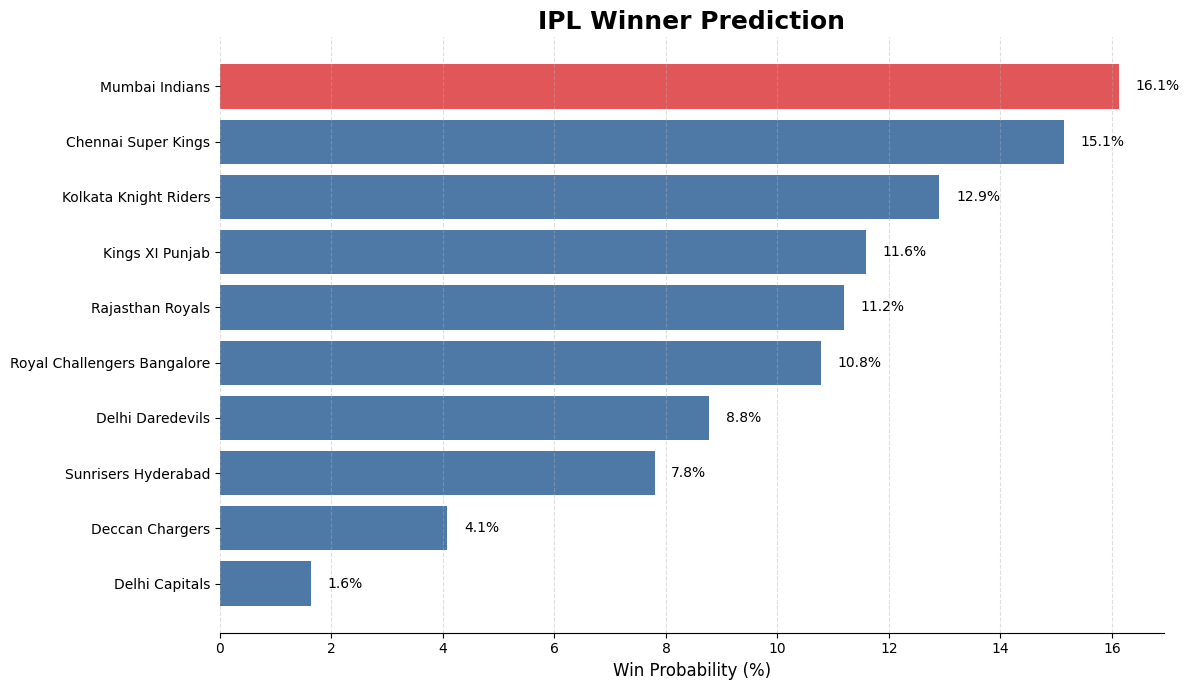

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

teams = le_y.classes_
probs = model.predict_proba(X_test)
avg_probs = np.mean(probs, axis=0) * 100

prob_df = pd.DataFrame({
    "Team": teams,
    "Win Probability": avg_probs
}).sort_values(by="Win Probability", ascending=True)

# 🎯 Professional color palette
base_color = "#4E79A7"      # soft blue
highlight_color = "#E15759" # premium red

# Highlight top team
max_index = prob_df["Win Probability"].idxmax()

colors = [
    highlight_color if i == max_index else base_color
    for i in prob_df.index
]

# Plot
bars = plt.barh(prob_df["Team"], prob_df["Win Probability"], 
                color=colors)

# Title
plt.title("IPL Winner Prediction", fontsize=18, fontweight='bold')

# Labels
plt.xlabel("Win Probability (%)", fontsize=12)

# Remove unnecessary borders
plt.gca().spines[['top','right','left']].set_visible(False)

# Subtle grid
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Value labels
for i, v in enumerate(prob_df["Win Probability"]):
    plt.text(v + 0.3, i, f"{v:.1f}%", 
             va='center', fontsize=10, fontweight='medium')

plt.tight_layout()
plt.savefig("linkedin_ip_prediction.png", dpi=300, bbox_inches='tight')
plt.show()

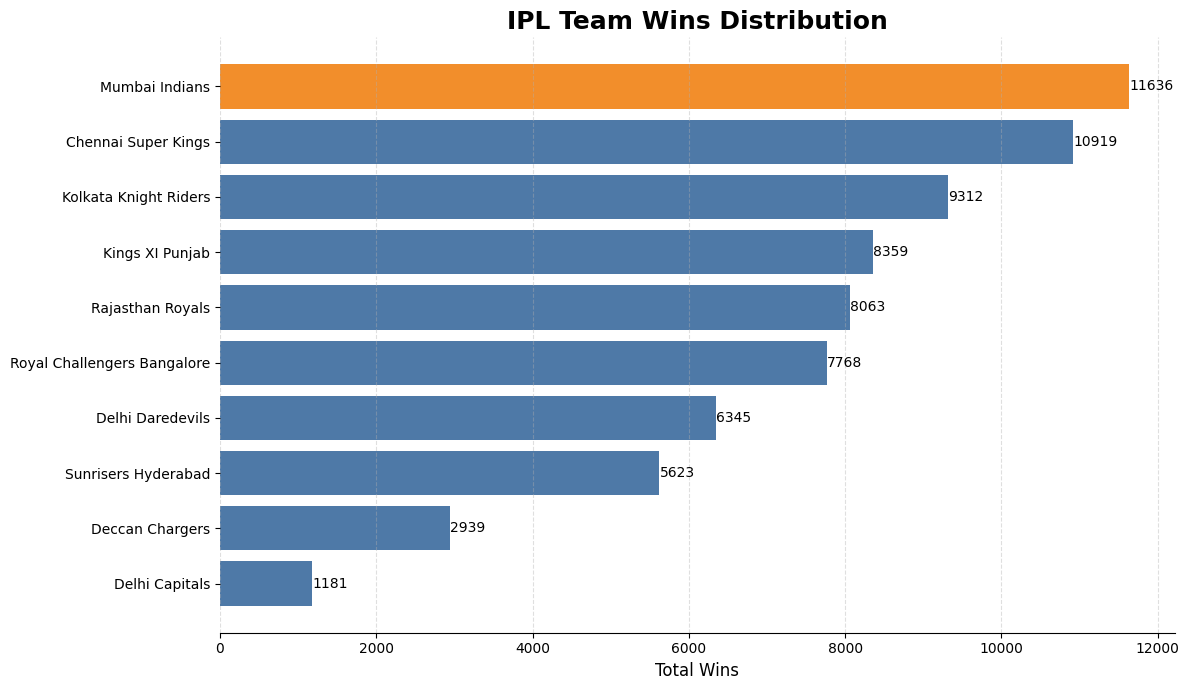

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

win_counts = df['winner'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(12,7))

# 🎯 Professional colors
base_color = "#4E79A7"      # soft blue
highlight_color = "#F28E2B" # elegant orange

# Highlight top team
max_value = win_counts.max()

colors = [
    highlight_color if v == max_value else base_color
    for v in win_counts.values
]

# Plot
bars = plt.barh(win_counts.index, win_counts.values, color=colors)

# Title
plt.title("IPL Team Wins Distribution", fontsize=18, fontweight='bold')

# Labels
plt.xlabel("Total Wins", fontsize=12)

# Clean look
plt.gca().spines[['top','right','left']].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Value labels
for i, v in enumerate(win_counts.values):
    plt.text(v + 2, i, str(v),
             va='center', fontsize=10, fontweight='medium')

plt.tight_layout()
plt.savefig("linkedin_team_wins.png", dpi=300, bbox_inches='tight')
plt.show()